In [21]:
# Standard library imports
import os
import json
from collections import Counter
from datetime import datetime

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from tqdm.notebook import tqdm
from pandas.io.json import json_normalize
from pandas.errors import SettingWithCopyWarning
import glob
import warnings
warnings.filterwarnings('ignore', category=pd.errors.SettingWithCopyWarning)

## 1. Get the list of unpatched devices, their last update date and last OS information

In [22]:
df_unpatched_samsung = pd.read_csv('../Data/Samsung/Samsung_unpatched_devices.csv') 
df_unpatched_xiaomi = pd.read_csv('../Data/Xiaomi/Xiaomi_unpatched_devices.csv') 
df_unpatched_oppo = pd.read_csv('../Data/Oppo/Oppo_unpatched_devices.csv') 
df_unpatched_google = pd.read_csv('../Data/Google/Google_unpatched_devices.csv') 

In [23]:
len(df_unpatched_samsung['device'].unique())

276

In [24]:
len(df_unpatched_samsung['id'])

21461

In [25]:
len(df_unpatched_xiaomi['device'].unique())

284

In [26]:
len(df_unpatched_xiaomi['id'].unique())

756

In [27]:
len(df_unpatched_oppo['device'].unique())

72

In [28]:
len(df_unpatched_oppo['id'].unique())

1124

In [29]:
len(df_unpatched_google['device'].unique())

20

In [30]:
len(df_unpatched_google['id'].unique())

20

## Hardware CVEs

In [31]:
path = '../Data/chipset-CVEs/'

files = sorted(glob.glob(path + '*.json'))[:]

print('Combining...')   
d = []
cves_all = []
for file in files[:]:
    print(file)
    base = os.path.basename(file)
    chipset = os.path.splitext(base)[0]
    
    df_new = pd.read_json(file)
    df_new2 = pd.json_normalize(df_new['vulnerabilities'])
    cves = list(set(df_new2['cve.id'].to_list()))
    cves_all = cves_all + cves
    
    cve_count = len(cves)
    cves_str = ','.join(cves)

    d.append({'chipset': chipset, 'cve': cves_str, 'cve_count': cve_count})
    
    
df_chipsets = pd.DataFrame(d)

df_chipsets.head()

Combining...
../Data/chipset-CVEs/h_intel_atom_x5-z8500.json
../Data/chipset-CVEs/h_mediatek_mt6750.json
../Data/chipset-CVEs/h_mediatek_mt6755.json
../Data/chipset-CVEs/h_mediatek_mt6761.json
../Data/chipset-CVEs/h_mediatek_mt6762.json
../Data/chipset-CVEs/h_mediatek_mt6763.json
../Data/chipset-CVEs/h_mediatek_mt6765.json
../Data/chipset-CVEs/h_mediatek_mt6765t.json
../Data/chipset-CVEs/h_mediatek_mt6769.json
../Data/chipset-CVEs/h_mediatek_mt6769z.json
../Data/chipset-CVEs/h_mediatek_mt6771.json
../Data/chipset-CVEs/h_mediatek_mt6779.json
../Data/chipset-CVEs/h_mediatek_mt6795.json
../Data/chipset-CVEs/h_mediatek_mt6797.json
../Data/chipset-CVEs/h_mediatek_mt6833.json
../Data/chipset-CVEs/h_mediatek_mt6853.json
../Data/chipset-CVEs/h_mediatek_mt6875.json
../Data/chipset-CVEs/h_mediatek_mt6877.json
../Data/chipset-CVEs/h_mediatek_mt6889.json
../Data/chipset-CVEs/h_mediatek_mt6893.json
../Data/chipset-CVEs/h_mediatek_mt6983.json
../Data/chipset-CVEs/h_mediatek_mt8176.json
../Data/chips

,chipset,cve,cve_count
0,h_intel_atom_x5-z8500,"CVE-2019-14615,CVE-2020-0551,CVE-2022-24436,CV...",4
1,h_mediatek_mt6750,"CVE-2021-0610,CVE-2021-0672,CVE-2022-20084,CVE...",35
2,h_mediatek_mt6755,"CVE-2021-0610,CVE-2021-0672,CVE-2022-20084,CVE...",32
3,h_mediatek_mt6761,"CVE-2022-21754,CVE-2023-20653,CVE-2021-0610,CV...",193
4,h_mediatek_mt6762,"CVE-2022-21754,CVE-2023-20653,CVE-2021-0610,CV...",147


## Read NIST database

In [32]:
dir_path = '../Data/NIST-all/'

print('Getting lists from {}'.format(dir_path))

import os, json, pandas as pd

# get JSON files (your v2.0 files)
txt_files = [os.path.join(dir_path, f) for f in os.listdir(dir_path) if f.endswith('.json')]
txt_files = sorted(txt_files)

print("Files found:", txt_files)

df_nist = pd.DataFrame([])
counter = 0

for file in txt_files:
    with open(file, 'r') as f:
        data = json.load(f)

    # 🔥 v2.0 format
    if 'vulnerabilities' in data:
        df_items = pd.json_normalize(data['vulnerabilities'])
    else:
        print(f"Skipping {file}")
        continue

    df_nist = pd.concat([df_nist, df_items], ignore_index=True)

    counter += 1
    print(f'Completed {counter} / {len(txt_files)}', end='\r')

print("\nColumns:", df_nist.columns)

# 🔥 find correct date column
date_col = None
for col in df_nist.columns:
    if "published" in col.lower():
        date_col = col
        break

if date_col is None:
    raise Exception("No published column found")

# convert + filter
df_nist[date_col] = pd.to_datetime(df_nist[date_col], errors='coerce')
df_nist = df_nist[df_nist[date_col] < "2023-06-28"]

# save
df_nist.to_csv('../Data/NIST_all.csv', index=False)

print('\n✅ Results written successfully')

Getting lists from ../Data/NIST-all/
Files found: ['../Data/NIST-all/nvdcve-2.0-2022.json', '../Data/NIST-all/nvdcve-2.0-2023.json']
Completed 2 / 2
Columns: Index(['cve.id', 'cve.sourceIdentifier', 'cve.published', 'cve.lastModified',
       'cve.vulnStatus', 'cve.cveTags', 'cve.descriptions',
       'cve.metrics.cvssMetricV31', 'cve.metrics.cvssMetricV2',
       'cve.weaknesses', 'cve.configurations', 'cve.references',
       'cve.metrics.cvssMetricV30', 'cve.cisaExploitAdd', 'cve.cisaActionDue',
       'cve.cisaRequiredAction', 'cve.cisaVulnerabilityName',
       'cve.metrics.cvssMetricV40', 'cve.evaluatorComment'],
      dtype='object')

✅ Results written successfully


In [33]:
df_nist = pd.read_csv('../Data/NIST_all.csv', low_memory=False)

cves_all = df_nist['cve.id'].dropna().unique().tolist()

hardware_cve_list = list(set(cves_all))

df_nist_hardware = df_nist[df_nist['cve.id'].isin(hardware_cve_list)].reset_index(drop=True)

df_nist_hardware['cve.sourceIdentifier'].value_counts()

cve@mitre.org                     8554
security-advisories@github.com    2152
contact@wpscan.com                1519
secure@microsoft.com              1428
cna@vuldb.com                     1362
                                  ... 
security@mautic.org                  1
psirt@thalesgroup.com                1
info@cybellum.com                    1
larry0@me.com                        1
productsecurity@bbraun.com           1
Name: cve.sourceIdentifier, Length: 227, dtype: int64

In [34]:
len(hardware_cve_list)

33411

## Assign to the devices

In [35]:
# Define the device vendors
vendors = ["Samsung", "Xiaomi", "Oppo", "Google"]

# Initialize an empty DataFrame
df_chipsets_all = pd.DataFrame()

# Loop over each vendor
for vendor in vendors:
    print('Done: {}!'.format(vendor))

    # Read excel file
    df_vendor = pd.read_excel('../Data/chipsets_v2.xlsx', sheet_name=vendor)

    # Add a new column with the vendor name
    df_vendor['vendor'] = vendor

    # Append the data from the vendor to df_chipsets_all
    df_chipsets_all = df_chipsets_all.append(df_vendor, ignore_index=True)

# Replace '\t' with an empty string for string columns
string_columns = ['chipset','cpe1', 'cpe2', 'cpe3', 'cpe4']
for column in string_columns:
    if df_chipsets_all[column].dtype == object:
        df_chipsets_all[column] = df_chipsets_all[column].str.replace('\t', '')

# Save the final DataFrame to an Excel file
df_chipsets_all.to_excel('../Data/chipsets_v3.xlsx', index=False)


Done: Samsung!
Done: Xiaomi!
Done: Oppo!
Done: Google!


/var/folders/03/cptgjt5d2v1f4dxrvkxkfymm0000gn/T/ipykernel_23771/1031451330.py:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_chipsets_all = df_chipsets_all.append(df_vendor, ignore_index=True)
/var/folders/03/cptgjt5d2v1f4dxrvkxkfymm0000gn/T/ipykernel_23771/1031451330.py:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_chipsets_all = df_chipsets_all.append(df_vendor, ignore_index=True)
/var/folders/03/cptgjt5d2v1f4dxrvkxkfymm0000gn/T/ipykernel_23771/1031451330.py:18: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  df_chipsets_all = df_chipsets_all.append(df_vendor, ignore_index=True)
/var/folders/03/cptgjt5d2v1f4dxrvkxkfymm0000gn/T/ipykernel_23771/1031451330.py:18: FutureWarning: The frame.append method is deprecat

### Find the CVEs from CPEs and assign them to the matching devices

In [36]:
import pandas as pd

df_nist = pd.read_csv('../Data/NIST_all.csv', low_memory=False)

# find configurations column automatically
config_col = [col for col in df_nist.columns if 'configurations' in col.lower()][0]

cpe_to_cves = {}

for _, row in df_nist.iterrows():
    cve_id = row['cve.id']
    config = str(row[config_col])

    parts = config.split("'")
    cpes = [p for p in parts if 'cpe:2.3' in p]

    for cpe in cpes:
        if cpe not in cpe_to_cves:
            cpe_to_cves[cpe] = set()
        cpe_to_cves[cpe].add(cve_id)

print("✅ CPE → CVE mapping built")

✅ CPE → CVE mapping built


In [37]:
import os

df_hardware = pd.read_excel('../Data/chipsets_v3.xlsx')

for idx, row in df_hardware.iterrows():

    cve_list = []

    for cpe_col in ['cpe1', 'cpe2', 'cpe3', 'cpe4']:
        cpe_val = row[cpe_col]

        if pd.notna(cpe_val):
            cpe_val = os.path.splitext(cpe_val)[0]

            for key in cpe_to_cves:
                if cpe_val in key:
                    cve_list.extend(list(cpe_to_cves[key]))

    cve_list_unique = list(set(cve_list))

    df_hardware.loc[idx, 'hardware_cves_all'] = ','.join(cve_list_unique)
    df_hardware.loc[idx, 'hardware_cves_all_count'] = len(cve_list_unique)

df_hardware['hardware_cves_all_count'] = df_hardware['hardware_cves_all_count'].fillna(0).astype(int)

print("✅ Hardware CVE mapping completed")

✅ Hardware CVE mapping completed


## Android Version CVEs

In [38]:
#Getting the descriptions and other details from NIST for unique Android CVEs
df_nist = pd.read_csv('../Data/NIST_all.csv', low_memory=False)
df_aosp = pd.read_csv('../Data/AOSP-bulletins.csv')

# 🔥 normalize description column
desc_col = 'cve.descriptions'

df_nist[desc_col] = df_nist[desc_col].astype(str)

df_aosp_with_version = df_aosp[~df_aosp['affected_versions'].isnull()]

# Samsung filter
df_samsung = df_nist[df_nist[desc_col].str.contains('SVE', na=False)]

# ---------- Android 13 ----------
df_nist_android_13 = df_nist[df_nist[desc_col].str.contains('Android-13', na=False)]['cve.id'].to_list()
df_aosp_13 = df_aosp_with_version[df_aosp_with_version['affected_versions'].str.contains('13', na=False)]['CVE'].to_list()
samsung_android_13 = df_samsung[df_samsung[desc_col].str.contains("T(13", regex=False, na=False)]['cve.id'].to_list()

df_android_13 = list(set(df_nist_android_13 + df_aosp_13 + samsung_android_13))
print('Android-13:', len(df_android_13))


# ---------- Android 12 ----------
df_nist_android_12 = df_nist[df_nist[desc_col].str.contains('Android-12', na=False)]['cve.id'].to_list()
df_aosp_12 = df_aosp_with_version[df_aosp_with_version['affected_versions'].str.contains('12', na=False)]['CVE'].to_list()
samsung_android_12 = df_samsung[df_samsung[desc_col].str.contains("S(12", regex=False, na=False)]['cve.id'].to_list()

df_android_12 = list(set(df_nist_android_12 + df_aosp_12 + samsung_android_12))
print('Android-12:', len(df_android_12))


# ---------- Android 11 ----------
df_nist_android_11 = df_nist[df_nist[desc_col].str.contains('Android-11', na=False)]['cve.id'].to_list()
df_aosp_11 = df_aosp_with_version[df_aosp_with_version['affected_versions'].str.contains('11', na=False)]['CVE'].to_list()
samsung_android_11 = df_samsung[df_samsung[desc_col].str.contains("R(11", regex=False, na=False)]['cve.id'].to_list()

df_android_11 = list(set(df_nist_android_11 + df_aosp_11 + samsung_android_11))
print('Android-11:', len(df_android_11))


# ---------- Android 10 ----------
df_nist_android_10 = df_nist[df_nist[desc_col].str.contains('Android-10', na=False)]['cve.id'].to_list()
df_aosp_10 = df_aosp_with_version[df_aosp_with_version['affected_versions'].str.contains('10', na=False)]['CVE'].to_list()
samsung_android_10 = df_samsung[df_samsung[desc_col].str.contains("Q(10", regex=False, na=False)]['cve.id'].to_list()

df_android_10 = list(set(df_nist_android_10 + df_aosp_10 + samsung_android_10))
print('Android-10:', len(df_android_10))


# ---------- Combine ----------
d_version_all = list(set(
    df_android_13 + df_android_12 + df_android_11 +
    df_android_10
))

df_version_all = df_nist[df_nist['cve.id'].isin(d_version_all)]

# 🔥 assigner column fix
df_version_all['cve.sourceIdentifier'].value_counts()



Android-13: 397
Android-12: 325
Android-11: 455
Android-10: 491


security@android.com           488
cve@mitre.org                    4
cve-coordination@google.com      1
Name: cve.sourceIdentifier, dtype: int64

In [39]:
len(d_version_all)

948

## Samsung - Match the impacting CVEs to devices through the last OS

In [40]:
import numpy as np  # 🔥 ensure this is present

# conditions
conditions = [
    df_unpatched_samsung['last_android_version'] == 'T(Android 13)',
    df_unpatched_samsung['last_android_version'] == 'S(Android 12)',
    df_unpatched_samsung['last_android_version'] == 'R(Android 11)',
    df_unpatched_samsung['last_android_version'] == 'Q(Android 10)',
    df_unpatched_samsung['last_android_version'] == 'Pie(Android 9)',
    df_unpatched_samsung['last_android_version'] == 'Oreo(Android 8.1.0)',
    df_unpatched_samsung['last_android_version'] == 'Oreo(Android 8.0.0)',
    df_unpatched_samsung['last_android_version'] == 'Nougat(Android 7.0)',
    df_unpatched_samsung['last_android_version'] == 'Nougat(Android 7.1.1)',
    df_unpatched_samsung['last_android_version'] == 'Marshmallow(Android 6.0.1)'
]

# 🔥 SAFE fallback for missing lists
def safe_list(x):
    return x if x is not None else []

# values (strings)
values = [
    ','.join(safe_list(df_android_13)),
    ','.join(safe_list(df_android_12)),
    ','.join(safe_list(df_android_11)),
    ','.join(safe_list(df_android_10)),
    ','.join(safe_list(globals().get('df_android_9', []))),
    ','.join(safe_list(globals().get('df_android_8_1', []))),
    ','.join(safe_list(globals().get('df_android_8_0', []))),
    ','.join(safe_list(globals().get('df_android_7_0', []))),
    ','.join(safe_list(globals().get('df_android_7_1_1', []))),
    ','.join(safe_list(globals().get('df_android_6_0_1', [])))
]

# values (counts)
values2 = [
    len(df_android_13),
    len(df_android_12),
    len(df_android_11),
    len(df_android_10),
    len(globals().get('df_android_9', [])),
    len(globals().get('df_android_8_1', [])),
    len(globals().get('df_android_8_0', [])),
    len(globals().get('df_android_7_0', [])),
    len(globals().get('df_android_7_1_1', [])),
    len(globals().get('df_android_6_0_1', []))
]

# assign
df_unpatched_samsung['version_CVE_list_all'] = np.select(conditions, values, default='')
df_unpatched_samsung['version_CVE_list_all_count'] = np.select(conditions, values2, default=0)

df_unpatched_samsung.head()

,id,device,last_android_version,last_update_date,version_CVE_list_all,version_CVE_list_all_count
0,SM-A530F/ORO,Galaxy A8 (2018),Pie(Android 9),2021-12-17,,0
1,SM-A530F/ORS,Galaxy A8 (2018),Pie(Android 9),2021-12-17,,0
2,SM-A530F/ORX,Galaxy A8 (2018),Pie(Android 9),2021-12-06,,0
3,SM-A530F/PAK,Galaxy A8 (2018),Pie(Android 9),2022-01-20,,0
4,SM-A530F/PAN,Galaxy A8 (2018),Pie(Android 9),2021-12-03,,0


## Xiaomi - Match the impacting CVEs to devices through the last OS

In [41]:
import numpy as np

#  ensure dataframe exists (IMPORTANT)
# if this errors, run previous cells or load it manually
# df_unpatched_xiaomi = pd.read_csv('../Data/unpatched_xiaomi.csv')

df_unpatched_xiaomi['last_android_version'] = df_unpatched_xiaomi['last_android_version'].astype(str)

# conditions
conditions = [
    df_unpatched_xiaomi['last_android_version'] == '13.0',
    df_unpatched_xiaomi['last_android_version'] == '12.0',
    df_unpatched_xiaomi['last_android_version'] == '11.0',
    df_unpatched_xiaomi['last_android_version'] == '10.0',
    df_unpatched_xiaomi['last_android_version'] == '9.0',
    df_unpatched_xiaomi['last_android_version'] == '8.1',
    df_unpatched_xiaomi['last_android_version'] == '8.0',
    df_unpatched_xiaomi['last_android_version'] == '7.0',
    df_unpatched_xiaomi['last_android_version'] == '7.1',
    df_unpatched_xiaomi['last_android_version'] == '6.0'
]

# safe getter for missing lists
def get_list(name):
    return globals().get(name, [])

# values (string lists)
values = [
    ','.join(get_list('df_android_13')),
    ','.join(get_list('df_android_12')),
    ','.join(get_list('df_android_11')),
    ','.join(get_list('df_android_10')),
    ','.join(get_list('df_android_9')),
    ','.join(get_list('df_android_8_1')),
    ','.join(get_list('df_android_8_0')),
    ','.join(get_list('df_android_7_0')),
    ','.join(get_list('df_android_7_1_1')),
    ','.join(get_list('df_android_6_0_1'))
]

# values (counts)
values2 = [
    len(get_list('df_android_13')),
    len(get_list('df_android_12')),
    len(get_list('df_android_11')),
    len(get_list('df_android_10')),
    len(get_list('df_android_9')),
    len(get_list('df_android_8_1')),
    len(get_list('df_android_8_0')),
    len(get_list('df_android_7_0')),
    len(get_list('df_android_7_1_1')),
    len(get_list('df_android_6_0_1'))
]

# assign with safe defaults
df_unpatched_xiaomi['version_CVE_list_all'] = np.select(conditions, values, default='')
df_unpatched_xiaomi['version_CVE_list_all_count'] = np.select(conditions, values2, default=0)

df_unpatched_xiaomi.head()

,id,device,last_android_version,last_update_date,version_CVE_list_all,version_CVE_list_all_count
0,HM2013022,Redmi 1 TD,4.4,2017-11-15,,0
1,HM2013023,Redmi 1 W,4.4,2018-09-26,,0
2,HM2013023_sg_global,Redmi 1 W,4.4,2015-12-24,,0
3,HM2014011,Redmi 1S TD 3G,4.4,2018-09-07,,0
4,HM2014501,Redmi 1S TD 4G,4.4,2018-09-07,,0


## Oppo - Match the impacting CVEs to devices through the last OS

In [42]:
import numpy as np

# ensure dataframe exists
# df_unpatched_oppo = pd.read_csv('../Data/unpatched_oppo.csv')

# convert properly (cleaner way)
df_unpatched_oppo['last_android_version'] = df_unpatched_oppo['last_android_version'].astype(float).astype(str)

# conditions
conditions = [
    df_unpatched_oppo['last_android_version'] == '13.0',
    df_unpatched_oppo['last_android_version'] == '12.0',
    df_unpatched_oppo['last_android_version'] == '11.0',
    df_unpatched_oppo['last_android_version'] == '10.0',
    df_unpatched_oppo['last_android_version'] == '9.0',
    df_unpatched_oppo['last_android_version'] == '8.1',
    df_unpatched_oppo['last_android_version'] == '8.0',
    df_unpatched_oppo['last_android_version'] == '7.0',
    df_unpatched_oppo['last_android_version'] == '7.1',
    df_unpatched_oppo['last_android_version'] == '6.0'
]

# safe getter
def get_list(name):
    return globals().get(name, [])

# values (string)
values = [
    ','.join(get_list('df_android_13')),
    ','.join(get_list('df_android_12')),
    ','.join(get_list('df_android_11')),
    ','.join(get_list('df_android_10')),
    ','.join(get_list('df_android_9')),
    ','.join(get_list('df_android_8_1')),
    ','.join(get_list('df_android_8_0')),
    ','.join(get_list('df_android_7_0')),
    ','.join(get_list('df_android_7_1_1')),
    ','.join(get_list('df_android_6_0_1'))
]

# values (count)
values2 = [
    len(get_list('df_android_13')),
    len(get_list('df_android_12')),
    len(get_list('df_android_11')),
    len(get_list('df_android_10')),
    len(get_list('df_android_9')),
    len(get_list('df_android_8_1')),
    len(get_list('df_android_8_0')),
    len(get_list('df_android_7_0')),
    len(get_list('df_android_7_1_1')),
    len(get_list('df_android_6_0_1'))
]

# assign (IMPORTANT: add defaults)
df_unpatched_oppo['version_CVE_list_all'] = np.select(conditions, values, default='')
df_unpatched_oppo['version_CVE_list_all_count'] = np.select(conditions, values2, default=0)

df_unpatched_oppo.head()

,id,device,last_android_version,last_update_date,version_CVE_list_all,version_CVE_list_all_count
0,https://support.oppo.com/dz/software-update/so...,OPPO Reno2 F,11.0,2021-05-10,"CVE-2023-20915,CVE-2020-0470,CVE-2021-39807,CV...",455
1,https://support.oppo.com/dz/software-update/so...,OPPO Reno3,11.0,2021-01-05,"CVE-2023-20915,CVE-2020-0470,CVE-2021-39807,CV...",455
2,https://support.oppo.com/dz/software-update/so...,OPPO A9 2020,11.0,2021-07-26,"CVE-2023-20915,CVE-2020-0470,CVE-2021-39807,CV...",455
3,https://support.oppo.com/dz/software-update/so...,OPPO A11k,11.0,2022-03-30,"CVE-2023-20915,CVE-2020-0470,CVE-2021-39807,CV...",455
4,https://support.oppo.com/dz/software-update/so...,OPPO A12,11.0,2022-03-30,"CVE-2023-20915,CVE-2020-0470,CVE-2021-39807,CV...",455


## Google - Match the impacting CVEs to devices through the last OS

In [43]:
import numpy as np

# 🔥 ensure dataframe exists
# df_unpatched_google = pd.read_csv('../Data/unpatched_google.csv')

df_unpatched_google['last_android_version'] = df_unpatched_google['last_android_version'].astype(str)

# conditions
conditions = [
    df_unpatched_google['last_android_version'] == '13.0.0',
    df_unpatched_google['last_android_version'] == '12.1.0',
    df_unpatched_google['last_android_version'] == '12.0.0',
    df_unpatched_google['last_android_version'] == '11.0.0',
    df_unpatched_google['last_android_version'] == '10.0.0',
    df_unpatched_google['last_android_version'] == '9.0.0',
    df_unpatched_google['last_android_version'] == '8.1.0',
    df_unpatched_google['last_android_version'] == '8.0.0',
    df_unpatched_google['last_android_version'] == '7.0.0',
    df_unpatched_google['last_android_version'] == '7.1.0',
    df_unpatched_google['last_android_version'] == '6.0.0'
]

# 🔥 safe getter
def get_list(name):
    return globals().get(name, [])

# values (strings)
values = [
    ','.join(get_list('df_android_13')),
    ','.join(get_list('df_android_12')),
    ','.join(get_list('df_android_12')),  # 12.1 → 12
    ','.join(get_list('df_android_11')),
    ','.join(get_list('df_android_10')),
    ','.join(get_list('df_android_9')),
    ','.join(get_list('df_android_8_1')),
    ','.join(get_list('df_android_8_0')),
    ','.join(get_list('df_android_7_0')),
    ','.join(get_list('df_android_7_1_1')),
    ','.join(get_list('df_android_6_0_1'))
]

# values (counts)
values2 = [
    len(get_list('df_android_13')),
    len(get_list('df_android_12')),
    len(get_list('df_android_12')),
    len(get_list('df_android_11')),
    len(get_list('df_android_10')),
    len(get_list('df_android_9')),
    len(get_list('df_android_8_1')),
    len(get_list('df_android_8_0')),
    len(get_list('df_android_7_0')),
    len(get_list('df_android_7_1_1')),
    len(get_list('df_android_6_0_1'))
]

# assign (IMPORTANT: default added)
df_unpatched_google['version_CVE_list_all'] = np.select(conditions, values, default='')
df_unpatched_google['version_CVE_list_all_count'] = np.select(conditions, values2, default=0)

df_unpatched_google.head()

,id,device,last_android_version,last_update_date,version_CVE_list_all,version_CVE_list_all_count
0,cheetah,Pixel 7 Pro,13.0.0,2023-03-01,"CVE-2023-20915,CVE-2022-20322,CVE-2022-20420,C...",397
1,panther,Pixel 7,13.0.0,2023-03-01,"CVE-2023-20915,CVE-2022-20322,CVE-2022-20420,C...",397
2,bluejay,Pixel 6a,13.0.0,2023-03-01,"CVE-2023-20915,CVE-2022-20322,CVE-2022-20420,C...",397
3,oriole,Pixel 6,13.0.0,2023-03-01,"CVE-2023-20915,CVE-2022-20322,CVE-2022-20420,C...",397
4,raven,Pixel 6 Pro,13.0.0,2023-03-01,"CVE-2023-20915,CVE-2022-20322,CVE-2022-20420,C...",397


In [44]:
df_unpatched_xiaomi.rename(columns={"name": "device"},inplace=True)
df_unpatched_xiaomi.rename(columns={"codename": "id"},inplace=True)
df_unpatched_oppo.rename(columns={"url": "id"},inplace=True)
df_unpatched_google.rename(columns={"codename": "id"},inplace=True)

In [45]:
# First, add a 'vendor' column to each DataFrame
df_unpatched_xiaomi['vendor'] = 'xiaomi'
df_unpatched_oppo['vendor'] = 'oppo'
df_unpatched_google['vendor'] = 'google'
df_unpatched_samsung['vendor'] = 'samsung'

# Then, concatenate the DataFrames vertically
df_unpatched_all = pd.concat([df_unpatched_xiaomi, df_unpatched_oppo, df_unpatched_google, df_unpatched_samsung], ignore_index=True)


In [46]:
df_unpatched_all.head()

,id,device,last_android_version,last_update_date,version_CVE_list_all,version_CVE_list_all_count,vendor
0,HM2013022,Redmi 1 TD,4.4,2017-11-15,,0,xiaomi
1,HM2013023,Redmi 1 W,4.4,2018-09-26,,0,xiaomi
2,HM2013023_sg_global,Redmi 1 W,4.4,2015-12-24,,0,xiaomi
3,HM2014011,Redmi 1S TD 3G,4.4,2018-09-07,,0,xiaomi
4,HM2014501,Redmi 1S TD 4G,4.4,2018-09-07,,0,xiaomi


## Combine Android version and hardware CVEs

In [47]:
df_unpatched_merged = df_unpatched_all.merge(df_hardware[['device', 'chipset','hardware_cves_all', 'hardware_cves_all_count']], 
                                   on='device', 
                                   how='left')

df_unpatched_merged.head()

,id,device,last_android_version,last_update_date,version_CVE_list_all,version_CVE_list_all_count,vendor,chipset,hardware_cves_all,hardware_cves_all_count
0,HM2013022,Redmi 1 TD,4.4,2017-11-15,,0,xiaomi,NaN,,0.0
1,HM2013023,Redmi 1 W,4.4,2018-09-26,,0,xiaomi,NaN,,0.0
2,HM2013023_sg_global,Redmi 1 W,4.4,2015-12-24,,0,xiaomi,NaN,,0.0
3,HM2014011,Redmi 1S TD 3G,4.4,2018-09-07,,0,xiaomi,Qualcomm MSM8228 Snapdragon 400 (28 nm),,0.0
4,HM2014501,Redmi 1S TD 4G,4.4,2018-09-07,,0,xiaomi,Qualcomm MSM8228 Snapdragon 400 (28 nm),,0.0


In [48]:
tqdm.pandas()

def process_row(row):
    version_CVE_list_all = row['version_CVE_list_all'].split(',')
    version_CVE_list_all_count = len(version_CVE_list_all)
    
    if row['hardware_cves_all_count']>0:
        hardware_cves_all_splitted = row['hardware_cves_all'].split(',')
        CVE_list_all_splitted = list(set(hardware_cves_all_splitted + version_CVE_list_all))
        CVE_list_all_splitted_count = row['hardware_cves_all_count'] + version_CVE_list_all_count
    else:
        CVE_list_all_splitted = version_CVE_list_all
        CVE_list_all_splitted_count = version_CVE_list_all_count

    row['CVE_list_all'] = ','.join(CVE_list_all_splitted)
    row['CVE_list_all_count'] = CVE_list_all_splitted_count
    
    return row

df_unpatched_merged['version_CVE_list_all_count'] = df_unpatched_merged['version_CVE_list_all'].apply(lambda x: len(x.split(',')))
df_unpatched_merged['CVE_list_all'] = ''
df_unpatched_merged['CVE_list_all_count'] = np.zeros(len(df_unpatched_merged), dtype=int)

df_unpatched_merged = df_unpatched_merged.progress_apply(process_row, axis=1)

df_unpatched_merged.head()

  0%|          | 0/23361 [00:00<?, ?it/s]

,id,device,last_android_version,last_update_date,version_CVE_list_all,version_CVE_list_all_count,vendor,chipset,hardware_cves_all,hardware_cves_all_count,CVE_list_all,CVE_list_all_count
0,HM2013022,Redmi 1 TD,4.4,2017-11-15,,1,xiaomi,NaN,,0.0,,1
1,HM2013023,Redmi 1 W,4.4,2018-09-26,,1,xiaomi,NaN,,0.0,,1
2,HM2013023_sg_global,Redmi 1 W,4.4,2015-12-24,,1,xiaomi,NaN,,0.0,,1
3,HM2014011,Redmi 1S TD 3G,4.4,2018-09-07,,1,xiaomi,Qualcomm MSM8228 Snapdragon 400 (28 nm),,0.0,,1
4,HM2014501,Redmi 1S TD 4G,4.4,2018-09-07,,1,xiaomi,Qualcomm MSM8228 Snapdragon 400 (28 nm),,0.0,,1


In [49]:
df_unpatched_merged['version_CVE_list_all_count'] = df_unpatched_merged['version_CVE_list_all_count'].astype(int)
df_unpatched_merged['hardware_cves_all_count'] = df_unpatched_merged['hardware_cves_all_count'].fillna(0).astype(int)
df_unpatched_merged['CVE_list_all_count'] = df_unpatched_merged['CVE_list_all_count'].astype(int)

df_unpatched_merged['last_update_date'] = pd.to_datetime(df_unpatched_merged['last_update_date'])

#DYNAMIC DEVICE RISK SCORE (NOVELTY)

In [50]:
# =====================================================
# MERGE ALL VENDOR DATAFRAMES
# =====================================================

import pandas as pd

df_unpatched_merged = pd.concat([
    df_unpatched_samsung,
    df_unpatched_xiaomi,
    df_unpatched_oppo,
    df_unpatched_google
], ignore_index=True)

print(df_unpatched_merged.shape)

print(df_unpatched_merged.columns)

(23361, 7)
Index(['id', 'device', 'last_android_version', 'last_update_date',
       'version_CVE_list_all', 'version_CVE_list_all_count', 'vendor'],
      dtype='object')


In [51]:
print(df_unpatched_merged.columns)

Index(['id', 'device', 'last_android_version', 'last_update_date',
       'version_CVE_list_all', 'version_CVE_list_all_count', 'vendor'],
      dtype='object')


## Align the EOLs and divide into quarters (~13 mins)

In [61]:
import pandas as pd
import numpy as np

warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)
tqdm.pandas()

# ---------- helper ----------
def get_cves(df_cves_filtered, start, end):
    cves = df_cves_filtered[
        (df_cves_filtered['days_after_eol'] < end) &
        (df_cves_filtered['days_after_eol'] >= start)
    ]['cve.id'].unique()
    return ','.join(cves)

# ---------- load ----------
df_nist = pd.read_csv('../Data/NIST_all.csv', low_memory=False)

# 🔥 FIX: correct column
date_col = [c for c in df_nist.columns if 'published' in c.lower()][0]
df_nist[date_col] = pd.to_datetime(df_nist[date_col], errors='coerce')

# ensure datetime
df_unpatched_merged['last_update_date'] = pd.to_datetime(df_unpatched_merged['last_update_date'], errors='coerce')

df_unpatched_merged['CVE_list_filtered'] = ''

# ---------- main ----------
def process_row(row):
    CVE_list_all = row.get('CVE_list_all', '')

    if not isinstance(CVE_list_all, str) or CVE_list_all.strip() == '':
        return row

    CVE_list_all_splitted = CVE_list_all.split(',')

    # 🔥 FIX: new column name
    df_cves = df_nist[df_nist['cve.id'].isin(CVE_list_all_splitted)]

    EOL_date = row['last_update_date']

    if pd.isna(EOL_date):
        return row

    # 🔥 FIX: use datetime directly
    df_cves_filtered = df_cves[df_cves[date_col] > EOL_date]

    if df_cves_filtered.empty:
        return row

    cves_filtered = df_cves_filtered['cve.id'].unique()

    row['CVE_list_filtered'] = ','.join(cves_filtered)
    row['CVE_list_filtered_count'] = len(cves_filtered)

    # 🔥 FIX: proper timedelta
    df_cves_filtered = df_cves_filtered.copy()
    df_cves_filtered['days_after_eol'] = (df_cves_filtered[date_col] - EOL_date).dt.days

    # ranges (quarters)
    ranges = [(i*90, (i+1)*90) for i in range(30)]

    for i, (start, end) in enumerate(ranges):
        row[f'CVE_list_q{i+1}'] = get_cves(df_cves_filtered, start, end)

    row['days_after_eol_max'] = df_cves_filtered['days_after_eol'].max()
    row['max_quarter_count'] = round(row['days_after_eol_max'] / 90)

    return row

# ---------- apply ----------
df_unpatched_merged = df_unpatched_merged.progress_apply(process_row, axis=1)

  0%|          | 0/23361 [00:00<?, ?it/s]

## SAFE USAGE WINDOW (NOVELTY)

In [75]:
# =========================================================
# FAST SAFE USAGE WINDOW
# =========================================================

import re

# ---------------------------------------------------------
# PRECOMPUTE CRITICAL CVE LOOKUP
# ---------------------------------------------------------

critical_lookup = {}

for _, row in df_nist.iterrows():

    cve_id = row.get('cve.id')

    if pd.isna(cve_id):
        continue

    row_text = str(row).upper()

    critical_lookup[cve_id] = (
        'CRITICAL' in row_text
    )

# ---------------------------------------------------------
# ESTIMATE SAFE WINDOW
# ---------------------------------------------------------

def estimate_safe_window(cve_string):

    if not isinstance(cve_string, str) or cve_string.strip() == '':
        return 0

    cves = list(set(cve_string.split(',')))

    critical_count = 0

    for cve in cves:

        if critical_lookup.get(cve, False):
            critical_count += 1

    # -----------------------------------------------------
    # WINDOW MODEL
    # -----------------------------------------------------

    if critical_count == 0:
        return 36

    elif critical_count <= 5:
        return 24

    elif critical_count <= 15:
        return 12

    elif critical_count <= 30:
        return 6

    else:
        return 3

# ---------------------------------------------------------
# APPLY
# ---------------------------------------------------------

df_unpatched_merged['SafeUsageWindow_months'] = df_unpatched_merged[
    'version_CVE_list_all'
].apply(estimate_safe_window)

# ---------------------------------------------------------
# RESULTS
# ---------------------------------------------------------

print(
    df_unpatched_merged[
        ['id','vendor','SafeUsageWindow_months']
    ].sample(30)
)

                     id   vendor  SafeUsageWindow_months
14174      SM-G970F/MWD  samsung                      36
2512       SM-G960F/XME  samsung                      36
7537      SM-G715U1/USC  samsung                      36
6119      SM-A105FN/SFR  samsung                      36
12061      SM-G955W/KDO  samsung                       0
9415       SM-S901E/CGU  samsung                      36
9197       SM-G990E/XFE  samsung                      36
13680      SM-A510F/THL  samsung                       0
18505      SM-N9810/BRI  samsung                      36
1507       SM-G965F/XTC  samsung                      36
21717  ido_xhdpi_global   xiaomi                       0
8693       SM-A235M/IUS  samsung                      36
19407      SM-G950F/BOG  samsung                       0
12855      SM-G930F/ECO  samsung                       0
6931      SM-A405FN/ITV  samsung                      36
12196     SM-J710FN/INS  samsung                       0
7592       SM-F700F/BGL  samsun

### DYNAMIC DEVICE RISK SCORE (NOVELTY)

In [73]:
# =========================================================
# IMPROVED DEVICE SECURITY RISK SCORE (DSRS)
# USING FULL DEVICE CVE EXPOSURE
# =========================================================

from tqdm import tqdm
import re

tqdm.pandas()

# =========================================================
# HELPER: EXTRACT CVSS SCORE
# =========================================================

def extract_cvss_score(row_text):

    nums = re.findall(r'\b\d+\.\d+\b', row_text)

    nums = [float(x) for x in nums]

    # valid CVSS scores
    nums = [x for x in nums if 0 <= x <= 10]

    if len(nums) == 0:
        return 5.0

    return max(nums)

# =========================================================
# COMPUTE DSRS
# =========================================================

def compute_risk(cve_string):

    if not isinstance(cve_string, str) or cve_string.strip() == '':
        return 0.0

    cve_ids = list(set(cve_string.split(',')))

    # IMPORTANT:
    # using FULL CVE exposure now
    df_temp = df_nist[
        df_nist['cve.id'].isin(cve_ids)
    ]

    total_risk = 0

    for _, row in df_temp.iterrows():

        row_text = str(row).upper()

        # =====================================================
        # BASE CVSS SCORE
        # =====================================================

        base_score = extract_cvss_score(row_text)

        # =====================================================
        # ATTACK VECTOR
        # =====================================================

        av = 1.0

        if 'NETWORK' in row_text:
            av = 1.5
        elif 'ADJACENT' in row_text:
            av = 1.2
        elif 'LOCAL' in row_text:
            av = 1.0
        elif 'PHYSICAL' in row_text:
            av = 0.5

        # =====================================================
        # USER INTERACTION
        # =====================================================

        ui = 1.0

        if 'NONE' in row_text:
            ui = 1.5
        elif 'REQUIRED' in row_text:
            ui = 1.0

        # =====================================================
        # ATTACK COMPLEXITY
        # =====================================================

        ac = 1.0

        if 'ATTACKCOMPLEXITY' in row_text and 'LOW' in row_text:
            ac = 1.5

        # =====================================================
        # FINAL RISK
        # =====================================================

        risk = base_score * av * ui * ac

        total_risk += risk

    return round(total_risk, 2)

# =========================================================
# IMPORTANT:
# USE FULL DEVICE CVE EXPOSURE
# =========================================================

df_unpatched_merged['DSRS'] = df_unpatched_merged[
    'CVE_list_all'
].progress_apply(compute_risk)

# =========================================================
# RESULTS
# =========================================================

print(
    df_unpatched_merged[
        ['id','vendor','DSRS']
    ].sort_values(
        by='DSRS',
        ascending=False
    ).head(30)
)

100%|█████████████████████████████████████| 23361/23361 [10:31<00:00, 37.02it/s]

                 id   vendor     DSRS
11680  SM-G780G/CAU  samsung  2243.35
10524  SM-X706B/ILO  samsung  2243.35
10530  SM-X706B/PAK  samsung  2243.35
10529  SM-X706B/MWD  samsung  2243.35
10528  SM-X706B/MM1  samsung  2243.35
10527  SM-X706B/MID  samsung  2243.35
10526  SM-X706B/KSA  samsung  2243.35
10525  SM-X706B/INU  samsung  2243.35
10523  SM-X706B/EGY  samsung  2243.35
10481  SM-T976B/XEF  samsung  2243.35
10522  SM-X706B/ECT  samsung  2243.35
10521  SM-X706B/CHO  samsung  2243.35
10520  SM-X706B/CAU  samsung  2243.35
10519  SM-X706B/BVO  samsung  2243.35
10518  SM-X706B/BRI  samsung  2243.35
10517  SM-X706B/AFR  samsung  2243.35
10531  SM-X706B/SEK  samsung  2243.35
10532  SM-X706B/SER  samsung  2243.35
10533  SM-X706B/SIN  samsung  2243.35
10534  SM-X706B/SKZ  samsung  2243.35
10535  SM-X706B/SLK  samsung  2243.35
10536  SM-X706B/STH  samsung  2243.35
10537  SM-X706B/TEL  samsung  2243.35
10538  SM-X706B/TGY  samsung  2243.35
10539  SM-X706B/THL  samsung  2243.35
10540  SM-X7

In [34]:
len(df_unpatched_merged['device'].unique())

652

In [35]:
len(df_unpatched_merged[df_unpatched_merged['max_quarter_count']>1]['id'].unique())

7404

In [36]:
len(df_unpatched_merged[df_unpatched_merged['max_quarter_count']>1]['device'].unique())

295

In [19]:
print(df_unpatched_merged.columns)

Index(['id', 'device', 'last_android_version', 'last_update_date', 'DSRS'], dtype='object')


In [37]:
df_unpatched_merged.groupby('vendor')['CVE_list_filtered_count'].mean()

vendor
google     158.263158
oppo       185.843416
samsung    125.789189
xiaomi      64.692058
Name: CVE_list_filtered_count, dtype: float64

In [38]:
df_unpatched_merged['device']

0            Redmi 1 TD
1             Redmi 1 W
2             Redmi 1 W
3        Redmi 1S TD 3G
4        Redmi 1S TD 4G
              ...      
23356       Galaxy S10e
23357       Galaxy S10e
23358       Galaxy S10e
23359       Galaxy S10e
23360       Galaxy S10e
Name: device, Length: 23361, dtype: object

### Case Study: "Galaxy Z Fold3 5G"

In [39]:
df_unpatched_merged[(df_unpatched_merged['vendor']=='samsung')&(df_unpatched_merged['max_quarter_count']==3)]['device'].unique()[:50]

array(['Galaxy A32 5G', 'Galaxy A33 5G', 'Galaxy A42 5G', 'Galaxy A51 5G',
       'Galaxy S9+', 'Galaxy Note10+', 'Galaxy S9', 'Galaxy S20+',
       'Galaxy A10s', 'Galaxy A20s', 'Galaxy A21', 'Galaxy M21',
       'Galaxy M31', 'Galaxy A6', 'Galaxy A6+', 'Galaxy A7 (2018)',
       'Galaxy Note9', 'Galaxy J4', 'Galaxy J6', 'Galaxy J8',
       'Galaxy A80', 'Galaxy A02', 'Galaxy A02s', 'Galaxy A03',
       'Galaxy A03 Core', 'Galaxy A03s', 'Galaxy A04', 'Galaxy A70',
       'Galaxy A10', 'Galaxy A12', 'Galaxy A20', 'Galaxy A20e',
       'Galaxy Z Fold3 5G', 'Galaxy XCover Pro', 'Galaxy Z Flip',
       'Galaxy Z Flip 5G', 'Galaxy Z Flip3 5G', 'Galaxy A13',
       'Galaxy A13 5G', 'Galaxy A22', 'Galaxy A23', 'Galaxy A31',
       'Galaxy S21 FE 5G', 'Galaxy S22', 'Galaxy S22 Ultra',
       'Galaxy S22+', 'Galaxy S20 Ultra', 'Galaxy Tab Active Pro',
       'Galaxy Tab A 10.1 (2019)', 'Galaxy A52'], dtype=object)

In [40]:
df_fold = df_unpatched_merged[(df_unpatched_merged['device']=='Galaxy Z Fold3 5G')&(df_unpatched_merged['max_quarter_count']==3)]

In [41]:
df_fold[['id','hardware_cves_all_count','version_CVE_list_all_count','CVE_list_filtered_count','CVE_list_filtered']]

,id,hardware_cves_all_count,version_CVE_list_all_count,CVE_list_filtered_count,CVE_list_filtered
9199,SM-F926U1/TMB,0,325,161.0,"CVE-2022-20392,CVE-2022-20393,CVE-2022-20395,C..."
9200,SM-F926U1/TMK,0,325,161.0,"CVE-2022-20392,CVE-2022-20393,CVE-2022-20395,C..."
9203,SM-F926U1/XAA,0,325,161.0,"CVE-2022-20392,CVE-2022-20393,CVE-2022-20395,C..."
9204,SM-F926U1/XAG,0,325,161.0,"CVE-2022-20392,CVE-2022-20393,CVE-2022-20395,C..."


In [43]:
fold_cves = df_fold[df_fold.id=='SM-F926U1/TMB']['CVE_list_filtered'].to_list()

if len(fold_cves) == 0 or not isinstance(fold_cves[0], str):
    fold_cves_unique = []
else:
    fold_cves_unique = fold_cves[0].split(',')

df_fold_V2 = df_nist[df_nist['cve.id'].isin(fold_cves_unique)]

In [46]:
# find correct column automatically
cvss_col = [col for col in df_fold_V2.columns if 'cvss' in col.lower()]

if len(cvss_col) == 0:
    raise Exception("No CVSS column found")

col = cvss_col[0]

print("Using column:", col)

df_fold_V2[col] = df_fold_V2[col].astype(str)

df_fold_V2[
    (df_fold_V2[col].str.contains('CRITICAL', na=False)) &
    (df_fold_V2[col].str.contains('NETWORK', na=False))
]

Using column: cve.metrics.cvssMetricV31


,cve.id,cve.sourceIdentifier,cve.published,cve.lastModified,cve.vulnStatus,cve.cveTags,cve.descriptions,cve.metrics.cvssMetricV31,cve.metrics.cvssMetricV2,cve.weaknesses,cve.configurations,cve.references,cve.metrics.cvssMetricV30,cve.cisaExploitAdd,cve.cisaActionDue,cve.cisaRequiredAction,cve.cisaVulnerabilityName,cve.metrics.cvssMetricV40,cve.evaluatorComment
18632,CVE-2022-20472,security@android.com,2022-12-13 16:15:15.947,2025-04-22T15:15:58.483,Modified,[],"[{'lang': 'en', 'value': 'In toLanguageTag of ...","[{'source': 'nvd@nist.gov', 'type': 'Primary',...",NaN,"[{'source': 'nvd@nist.gov', 'type': 'Primary',...","[{'nodes': [{'operator': 'OR', 'negate': False...",[{'url': 'https://source.android.com/security/...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18633,CVE-2022-20473,security@android.com,2022-12-13 16:15:16.000,2025-04-22T15:15:58.640,Modified,[],"[{'lang': 'en', 'value': 'In toLanguageTag of ...","[{'source': 'nvd@nist.gov', 'type': 'Primary',...",NaN,"[{'source': 'nvd@nist.gov', 'type': 'Primary',...","[{'nodes': [{'operator': 'OR', 'negate': False...",[{'url': 'https://source.android.com/security/...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25784,CVE-2023-20946,security@android.com,2023-02-28 17:15:11.090,2025-03-21T19:15:43.180,Modified,[],"[{'lang': 'en', 'value': 'In onStart of Blueto...","[{'source': 'nvd@nist.gov', 'type': 'Primary',...",NaN,"[{'source': 'nvd@nist.gov', 'type': 'Primary',...","[{'nodes': [{'operator': 'OR', 'negate': False...",[{'url': 'https://source.android.com/security/...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27089,CVE-2023-20951,security@android.com,2023-03-24 20:15:09.497,2025-02-25T22:15:12.467,Modified,[],"[{'lang': 'en', 'value': 'In gatt_process_prep...","[{'source': 'nvd@nist.gov', 'type': 'Primary',...",NaN,"[{'source': 'nvd@nist.gov', 'type': 'Primary',...","[{'nodes': [{'operator': 'OR', 'negate': False...",[{'url': 'https://source.android.com/security/...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27092,CVE-2023-20954,security@android.com,2023-03-24 20:15:09.637,2025-02-25T17:15:11.873,Modified,[],"[{'lang': 'en', 'value': 'In SDP_AddAttribute ...","[{'source': 'nvd@nist.gov', 'type': 'Primary',...",NaN,"[{'source': 'nvd@nist.gov', 'type': 'Primary',...","[{'nodes': [{'operator': 'OR', 'negate': False...",[{'url': 'https://source.android.com/security/...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
29066,CVE-2023-21096,security@android.com,2023-04-19 20:15:11.850,2025-02-05T16:15:34.750,Modified,[],"[{'lang': 'en', 'value': 'In OnWakelockRelease...","[{'source': 'nvd@nist.gov', 'type': 'Primary',...",NaN,"[{'source': 'nvd@nist.gov', 'type': 'Primary',...","[{'nodes': [{'operator': 'OR', 'negate': False...",[{'url': 'https://source.android.com/security/...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
df_fold = df_unpatched_merged[(df_unpatched_merged['device']=='Galaxy Z Fold3 5G')&(df_unpatched_merged['max_quarter_count']==3)]

### Calculate the statistics for quarters (~5mins)

In [ ]:
df_final = df_unpatched_merged.copy()

d = []
critical_sum = 0
high_sum = 0
medium_sum = 0
low_sum = 0

cve_per_pair_accumulated = 0
critical_per_pair_accumulated = 0
high_per_pair_accumulated = 0
medium_per_pair_accumulated = 0
low_per_pair_accumulated = 0


cond1 = ~df_final['CVE_list_filtered'].isnull()
cond2 = df_final['CVE_list_filtered']!=''
cond3 = df_final['CVE_list_filtered_count']>0
df_final_v2 = df_final[cond1&cond2&cond3]

print('{} unsupported devices'.format(len(df_final_v2.index)))

for i in tqdm(range(1, 31), desc="Processing Quarters"): 
    
    q = 'CVE_list_q'+str(i)
    
    cond1 = ~df_final_v2[q].isnull()
    cond2 = df_final_v2[q]!=''
    cond3 = df_final_v2['max_quarter_count']>=(i-1)

    df_final_active = df_final_v2[cond1&cond2&cond3]
    
    pair_count=len(df_final_active['id'].unique())
    #model_count=len(df_final_active['device'].unique())
    #device_count=len(df_final_active['device'].unique())
        
    q_cves_all = []
    for l in df_final_active[q].str.split(','):
        q_cves_all = q_cves_all + l
        
    q_cves_unique = list(set(q_cves_all))

    df_q = df_nist[df_nist['cve.CVE_data_meta.ID'].isin(q_cves_all)]
    
    total_cve_count = len(q_cves_all)
    unique_cve_count = len(q_cves_unique)
    
    if pair_count==0:
        cve_per_pair=0
    else:
        cve_per_pair = total_cve_count/pair_count
    
    cve_per_pair_accumulated = cve_per_pair_accumulated + cve_per_pair

    #SEVERITY
    # Convert the list to a Counter
    counter_q_cves_all = Counter(q_cves_all)
    # Now, for each 'critical_cves', look up its count in 'counter_q_cves_all'
    critical_cves = df_q[df_q['impact.baseMetricV3.cvssV3.baseSeverity']=='CRITICAL']['cve.CVE_data_meta.ID'].tolist()
    critical_count = sum(counter_q_cves_all[cve] for cve in critical_cves)
    # Now, for each 'high_cves', look up its count in 'counter_q_cves_all'
    high_cves = df_q[df_q['impact.baseMetricV3.cvssV3.baseSeverity']=='HIGH']['cve.CVE_data_meta.ID'].tolist()
    high_count = sum(counter_q_cves_all[cve] for cve in high_cves)
    # Now, for each 'medium_cves', look up its count in 'counter_q_cves_all'
    medium_cves = df_q[df_q['impact.baseMetricV3.cvssV3.baseSeverity']=='MEDIUM']['cve.CVE_data_meta.ID'].tolist()
    medium_count = sum(counter_q_cves_all[cve] for cve in medium_cves)
    # Now, for each 'low_cves', look up its count in 'counter_q_cves_all'
    low_cves = df_q[df_q['impact.baseMetricV3.cvssV3.baseSeverity']=='LOW']['cve.CVE_data_meta.ID'].tolist()
    low_count = sum(counter_q_cves_all[cve] for cve in low_cves)
    
        
    if pair_count==0:
        critical_per_pair=0
        high_per_pair=0
        medium_per_pair=0
        low_per_pair=0
    else:
        critical_per_pair = critical_count/pair_count
        high_per_pair = high_count/pair_count
        medium_per_pair = medium_count/pair_count
        low_per_pair = low_count/pair_count
    
    critical_per_pair_accumulated = critical_per_pair_accumulated + critical_per_pair
    high_per_pair_accumulated = high_per_pair_accumulated + high_per_pair
    medium_per_pair_accumulated = medium_per_pair_accumulated + medium_per_pair
    low_per_pair_accumulated = low_per_pair_accumulated + low_per_pair
    
    
    #USER INTERACTION
    none_count = len(df_q[df_q['impact.baseMetricV3.cvssV3.userInteraction']=='NONE'].index)
    required_count = len(df_q[df_q['impact.baseMetricV3.cvssV3.userInteraction']=='REQUIRED'].index)
    
    if pair_count==0:
        none_per=0
        required_per=0
    else:     
        none_per = (none_count*100)/(none_count+required_count)
        required_per = (required_count*100)/(none_count+required_count)
    
    
    #COMPLEXITY
    low_comp_count = len(df_q[df_q['impact.baseMetricV2.cvssV2.accessComplexity']=='LOW'].index)
    medium_comp_count = len(df_q[df_q['impact.baseMetricV2.cvssV2.accessComplexity']=='MEDIUM'].index)
    high_comp_count = len(df_q[df_q['impact.baseMetricV2.cvssV2.accessComplexity']=='HIGH'].index)
        
    if pair_count==0:
        low_comp_per=0
        medium_comp_per=0
        high_com_per=0
    else:     
        low_comp_per = (low_comp_count*100)/(low_comp_count+medium_comp_count+high_comp_count)
        medium_comp_per = (medium_comp_count*100)/(low_comp_count+medium_comp_count+high_comp_count)
        high_com_per = (high_comp_count*100)/(low_comp_count+medium_comp_count+high_comp_count)
    
    
    #ATTACK VECTOR
    local_count = len(df_q[df_q['impact.baseMetricV3.cvssV3.attackVector']=='LOCAL'].index)
    adjacent_network_count = len(df_q[df_q['impact.baseMetricV3.cvssV3.attackVector']=='ADJACENT_NETWORK'].index)
    network_count = len(df_q[df_q['impact.baseMetricV3.cvssV3.attackVector']=='NETWORK'].index)
    physical_count = len(df_q[df_q['impact.baseMetricV3.cvssV3.attackVector']=='PHYSICAL'].index)
    
    if pair_count==0:
        local_per=0
        adjacent_network_per=0
        network_per=0
        physical_per=0
    else:     
        local_per = (local_count*100)/(local_count+adjacent_network_count+network_count+physical_count)
        adjacent_network_per = (adjacent_network_count*100)/(local_count+adjacent_network_count+network_count+physical_count)
        network_per = (network_count*100)/(local_count+adjacent_network_count+network_count+physical_count)
        physical_per = (physical_count*100)/(local_count+adjacent_network_count+network_count+physical_count)
    
    #EXTRA 
    #userInteraction=='NONE' & Severity=='CRITICAL'
    none_critical_count = len(df_q[(df_q['impact.baseMetricV3.cvssV3.userInteraction']=='NONE')&(df_q['impact.baseMetricV3.cvssV3.baseSeverity']=='CRITICAL')].index)
        
    if pair_count==0:
        none_critical_count_per=0
    else:
        none_critical_count_per = (none_critical_count*100)/(none_count+required_count)
    
    #userInteraction=='NONE' & Severity=='HIGH'
    none_high_count = len(df_q[(df_q['impact.baseMetricV3.cvssV3.userInteraction']=='NONE')&(df_q['impact.baseMetricV3.cvssV3.baseSeverity']=='HIGH')].index)
    
    if pair_count==0:
        none_high_count_per=0
    else:
        none_high_count_per = (none_high_count*100)/(none_count+required_count)
    
    
    d.append({'period': i, 
              'total_cve_count': total_cve_count,
              'unique_cve_count': unique_cve_count,
              'pair_count': pair_count,
              'cve_per_pair':cve_per_pair,
              'cve_per_pair_accumulated':cve_per_pair_accumulated,
              'critical_count': critical_count,
              'high_count':high_count,
              'medium_count':medium_count,
              'low_count':low_count,
              'critical_per_pair':critical_per_pair,
              'high_per_pair':high_per_pair,
              'medium_per_pair':medium_per_pair,
              'low_per_pair':low_per_pair,
              'critical_per_pair_accumulated':critical_per_pair_accumulated,
              'high_per_pair_accumulated':high_per_pair_accumulated,
              'medium_per_pair_accumulated':medium_per_pair_accumulated,
              'low_per_pair_accumulated':low_per_pair_accumulated,
              'none_count':none_count,
              'required_count':required_count,
              'none_per': none_per,
              'required_per': required_per,
              'low_comp_count': low_comp_count,
              'medium_comp_per': medium_comp_per,
              'high_comp_count': high_comp_count,
              'low_comp_per': low_comp_per,
              'high_com_per': high_com_per,
              'local_count': local_count,
              'network_count': network_count,
              'local_per': local_per,
              'adjacent_network_per':adjacent_network_per,
              'network_per': network_per,
              'physical_per':physical_per,
              'none_critical_count': none_critical_count,
              'none_critical_count_per': none_critical_count_per,
              'none_high_count': none_high_count,
              'none_high_count_per':none_high_count_per
             })
    
df_quarters = pd.DataFrame(d)
df_quarters.head()

### Severity

In [51]:
df_quarters = pd.DataFrame()

# get all quarter columns
quarter_cols = [col for col in df_unpatched_merged.columns if 'CVE_list_q' in col]
quarter_cols = sorted(quarter_cols, key=lambda x: int(x.split('q')[1]))

for i, col in enumerate(quarter_cols):
    df_quarters.loc[i, 'period'] = i + 1

    # count severity using df_nist mapping
    cve_lists = df_unpatched_merged[col].fillna('').astype(str)

    all_cves = []
    for cve_str in cve_lists:
        if cve_str:
            all_cves.extend(cve_str.split(','))

    if len(all_cves) == 0:
        df_quarters.loc[i, ['critical_per_pair_accumulated',
                            'high_per_pair_accumulated',
                            'medium_per_pair_accumulated',
                            'low_per_pair_accumulated']] = 0
        continue

    df_temp = df_nist[df_nist['cve.id'].isin(all_cves)].copy()

    # 🔥 find severity column automatically
    sev_col = [c for c in df_temp.columns if 'severity' in c.lower()]
    if len(sev_col) == 0:
        # fallback: use string search
        df_temp['severity'] = df_temp.astype(str).apply(lambda x: ' '.join(x), axis=1)
        sev_col = ['severity']

    sev_col = sev_col[0]

    df_temp[sev_col] = df_temp[sev_col].astype(str)

    df_quarters.loc[i, 'critical_per_pair_accumulated'] = df_temp[sev_col].str.contains('CRITICAL', na=False).sum()
    df_quarters.loc[i, 'high_per_pair_accumulated'] = df_temp[sev_col].str.contains('HIGH', na=False).sum()
    df_quarters.loc[i, 'medium_per_pair_accumulated'] = df_temp[sev_col].str.contains('MEDIUM', na=False).sum()
    df_quarters.loc[i, 'low_per_pair_accumulated'] = df_temp[sev_col].str.contains('LOW', na=False).sum()

df_quarters.head()

,period,critical_per_pair_accumulated,high_per_pair_accumulated,medium_per_pair_accumulated,low_per_pair_accumulated
0,1.0,17.0,367.0,186.0,385.0
1,2.0,17.0,319.0,156.0,323.0
2,3.0,15.0,222.0,89.0,226.0
3,4.0,13.0,210.0,81.0,213.0
4,5.0,13.0,202.0,78.0,205.0


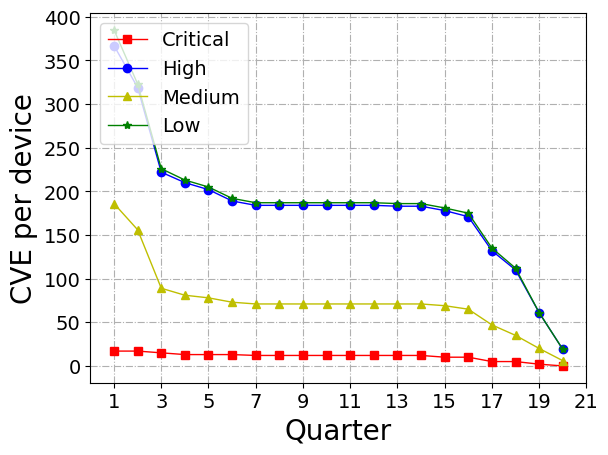

critical_per_pair_accumulated     10.80
high_per_pair_accumulated        182.50
medium_per_pair_accumulated       73.65
low_per_pair_accumulated         186.05
dtype: float64


,critical_per_pair_accumulated,high_per_pair_accumulated,medium_per_pair_accumulated,low_per_pair_accumulated
period,,,,
1.0,17.0,367.0,186.0,385.0
2.0,17.0,319.0,156.0,323.0
3.0,15.0,222.0,89.0,226.0
4.0,13.0,210.0,81.0,213.0
5.0,13.0,202.0,78.0,205.0
6.0,13.0,189.0,73.0,192.0
7.0,12.0,184.0,71.0,187.0
8.0,12.0,184.0,71.0,187.0
9.0,12.0,184.0,71.0,187.0


<Figure size 640x480 with 0 Axes>

In [52]:
df_plot = df_quarters[df_quarters['period'] < 21][['period','critical_per_pair_accumulated','high_per_pair_accumulated','medium_per_pair_accumulated','low_per_pair_accumulated']]

df_plot.set_index('period',inplace=True)
styles = ['rs-','bo-','y^-','g*-']
df_plot.plot(style=styles,linewidth=1)
plt.xlabel('Quarter',fontsize=20)
plt.ylabel('CVE per device',fontsize=20)
plt.xticks(list(range(1, 22, 2)),list(range(1, 22, 2)),fontsize=14)
plt.yticks(fontsize=14)
plt.grid(linestyle='-.')
plt.legend(['Critical','High','Medium','Low'],fontsize=14,loc=2)
plt.xlim(0, 21)
plt.savefig('../Results/unsupported_severity_v2.pdf', bbox_inches='tight')
plt.show()
plt.tight_layout()

print(df_plot.mean())

df_plot

In [53]:
df_plot['critical_per_pair_accumulated']+df_plot['high_per_pair_accumulated']+df_plot['medium_per_pair_accumulated']+df_plot['low_per_pair_accumulated']

period
1.0     955.0
2.0     815.0
3.0     552.0
4.0     517.0
5.0     498.0
6.0     467.0
7.0     454.0
8.0     454.0
9.0     454.0
10.0    454.0
11.0    454.0
12.0    454.0
13.0    452.0
14.0    452.0
15.0    438.0
16.0    421.0
17.0    319.0
18.0    262.0
19.0    144.0
20.0     44.0
dtype: float64

### User Interaction

In [55]:
df_quarters = pd.DataFrame()

quarter_cols = [col for col in df_unpatched_merged.columns if 'CVE_list_q' in col]
quarter_cols = sorted(quarter_cols, key=lambda x: int(x.split('q')[1]))

for i, col in enumerate(quarter_cols):
    df_quarters.loc[i, 'period'] = i + 1

    cve_lists = df_unpatched_merged[col].fillna('').astype(str)

    all_cves = []
    for cve_str in cve_lists:
        if cve_str:
            all_cves.extend(cve_str.split(','))

    df_temp = df_nist[df_nist['cve.id'].isin(all_cves)].copy()

    if df_temp.empty:
        df_quarters.loc[i, ['critical_per_pair_accumulated',
                            'high_per_pair_accumulated',
                            'medium_per_pair_accumulated',
                            'low_per_pair_accumulated']] = 0
        continue

    # detect severity column
    sev_col = [c for c in df_temp.columns if 'severity' in c.lower()]
    if len(sev_col) == 0:
        df_temp['severity'] = df_temp.astype(str).apply(lambda x: ' '.join(x), axis=1)
        sev_col = ['severity']

    sev_col = sev_col[0]
    df_temp[sev_col] = df_temp[sev_col].astype(str)

    df_quarters.loc[i, 'critical_per_pair_accumulated'] = df_temp[sev_col].str.contains('CRITICAL', na=False).sum()
    df_quarters.loc[i, 'high_per_pair_accumulated'] = df_temp[sev_col].str.contains('HIGH', na=False).sum()
    df_quarters.loc[i, 'medium_per_pair_accumulated'] = df_temp[sev_col].str.contains('MEDIUM', na=False).sum()
    df_quarters.loc[i, 'low_per_pair_accumulated'] = df_temp[sev_col].str.contains('LOW', na=False).sum()

df_quarters.head()

,period,critical_per_pair_accumulated,high_per_pair_accumulated,medium_per_pair_accumulated,low_per_pair_accumulated
0,1.0,17.0,367.0,186.0,385.0
1,2.0,17.0,319.0,156.0,323.0
2,3.0,15.0,222.0,89.0,226.0
3,4.0,13.0,210.0,81.0,213.0
4,5.0,13.0,202.0,78.0,205.0


In [56]:
total = (
    df_quarters['critical_per_pair_accumulated'] +
    df_quarters['high_per_pair_accumulated'] +
    df_quarters['medium_per_pair_accumulated'] +
    df_quarters['low_per_pair_accumulated']
)

df_quarters['required_per'] = (
    (df_quarters['critical_per_pair_accumulated'] +
     df_quarters['high_per_pair_accumulated']) / total * 100
)

df_quarters['none_per'] = (
    (df_quarters['medium_per_pair_accumulated'] +
     df_quarters['low_per_pair_accumulated']) / total * 100
)

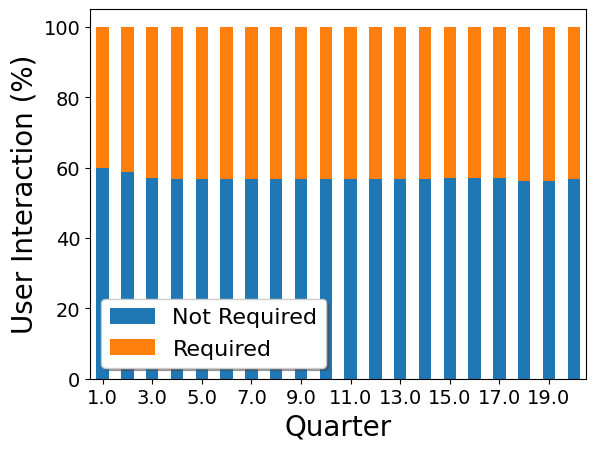

none_per        57.053345
required_per    42.946655
dtype: float64


,none_per,required_per
period,,
1.0,59.790576,40.209424
2.0,58.773006,41.226994
3.0,57.065217,42.934783
4.0,56.866538,43.133462
5.0,56.827309,43.172691
6.0,56.745182,43.254818
7.0,56.828194,43.171806
8.0,56.828194,43.171806
9.0,56.828194,43.171806


<Figure size 640x480 with 0 Axes>

In [57]:
df_plot = df_quarters[df_quarters['period'] < 21][['period','none_per','required_per']]
df_plot.set_index('period',inplace=True)

df_plot.plot(kind='bar',stacked=True)
plt.xlabel('Quarter',fontsize=20)
plt.ylabel('User Interaction (%)',fontsize=20)
plt.xticks(fontsize=14,rotation = 0)
plt.yticks(fontsize=14)
plt.gca().xaxis.set_major_locator(plt.MultipleLocator(2))
plt.gca().yaxis.set_major_locator(plt.MultipleLocator(20))
plt.legend(['Not Required','Required'],fontsize=16,loc=3,shadow=True)
plt.savefig('../Results/unsupported_user_interaction_v2.pdf', bbox_inches='tight')
plt.show()
plt.tight_layout()

print(df_plot.mean())

df_plot


### Attack Complexity

In [59]:
# ---------- ATTACK COMPLEXITY ----------

df_quarters['low_comp_per'] = 0
df_quarters['medium_comp_per'] = 0
df_quarters['high_com_per'] = 0

quarter_cols = [col for col in df_unpatched_merged.columns if 'CVE_list_q' in col]
quarter_cols = sorted(quarter_cols, key=lambda x: int(x.split('q')[1]))

for i, col in enumerate(quarter_cols):
    
    cve_lists = df_unpatched_merged[col].fillna('').astype(str)

    all_cves = []
    for cve_str in cve_lists:
        if cve_str:
            all_cves.extend(cve_str.split(','))

    if len(all_cves) == 0:
        continue

    df_temp = df_nist[df_nist['cve.id'].isin(all_cves)].copy()

    # 🔥 find attack complexity column
    comp_col = [c for c in df_temp.columns if 'attackcomplexity' in c.lower()]

    if len(comp_col) == 0:
        # fallback
        df_temp['comp'] = df_temp.astype(str).apply(lambda x: ' '.join(x), axis=1)
        comp_col = ['comp']

    comp_col = comp_col[0]
    df_temp[comp_col] = df_temp[comp_col].astype(str)

    low = df_temp[comp_col].str.contains('LOW', na=False).sum()
    high = df_temp[comp_col].str.contains('HIGH', na=False).sum()

    total = low + high

    if total == 0:
        continue

    df_quarters.loc[i, 'low_comp_per'] = (low / total) * 100
    df_quarters.loc[i, 'high_com_per'] = (high / total) * 100
    df_quarters.loc[i, 'medium_comp_per'] = 0  # usually not present

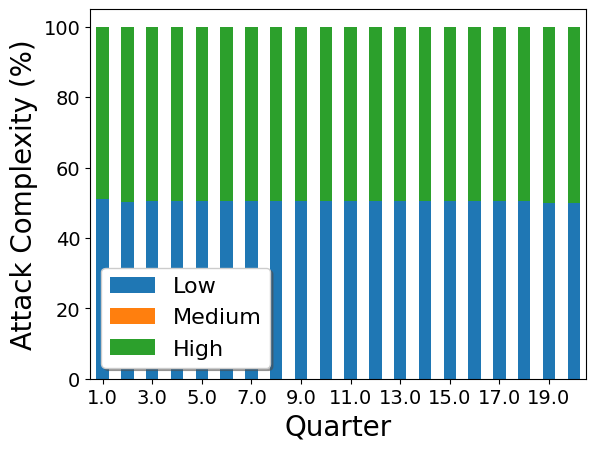

low_comp_per       50.415931
medium_comp_per     0.000000
high_com_per       49.584069
dtype: float64


,low_comp_per,medium_comp_per,high_com_per
period,,,
1.0,51.196809,0,48.803191
2.0,50.311526,0,49.688474
3.0,50.446429,0,49.553571
4.0,50.354610,0,49.645390
5.0,50.368550,0,49.631450
6.0,50.393701,0,49.606299
7.0,50.404313,0,49.595687
8.0,50.404313,0,49.595687
9.0,50.404313,0,49.595687


<Figure size 640x480 with 0 Axes>

In [60]:
df_plot = df_quarters[df_quarters['period'] < 21][['period','low_comp_per','medium_comp_per','high_com_per']]

df_plot.set_index('period',inplace=True)
hatches = ["*", "/", "o", "x"]

bars = df_plot.plot(kind='bar',stacked=True)
plt.xlabel('Quarter',fontsize=20)
plt.ylabel('Attack Complexity (%)',fontsize=20)
plt.xticks(fontsize=14,rotation = 0)
plt.yticks(fontsize=14)
plt.gca().xaxis.set_major_locator(plt.MultipleLocator(2))
plt.gca().yaxis.set_major_locator(plt.MultipleLocator(20))
plt.legend(['Low','Medium','High'],fontsize=16,loc=3,shadow=True)
plt.savefig('../Results/unsupported_attack_complexity_v2.pdf', bbox_inches='tight')
plt.show()
plt.tight_layout()

print(df_plot.mean())

df_plot

### Attack Vector

In [62]:
# ---------- ATTACK VECTOR ----------

df_quarters['local_per'] = 0
df_quarters['adjacent_network_per'] = 0
df_quarters['network_per'] = 0
df_quarters['physical_per'] = 0

quarter_cols = [col for col in df_unpatched_merged.columns if 'CVE_list_q' in col]
quarter_cols = sorted(quarter_cols, key=lambda x: int(x.split('q')[1]))

for i, col in enumerate(quarter_cols):
    
    cve_lists = df_unpatched_merged[col].fillna('').astype(str)

    all_cves = []
    for cve_str in cve_lists:
        if cve_str:
            all_cves.extend(cve_str.split(','))

    if len(all_cves) == 0:
        continue

    df_temp = df_nist[df_nist['cve.id'].isin(all_cves)].copy()

    # 🔥 detect attack vector column
    vec_col = [c for c in df_temp.columns if 'attackvector' in c.lower()]

    if len(vec_col) == 0:
        df_temp['vec'] = df_temp.astype(str).apply(lambda x: ' '.join(x), axis=1)
        vec_col = ['vec']

    vec_col = vec_col[0]
    df_temp[vec_col] = df_temp[vec_col].astype(str)

    local = df_temp[vec_col].str.contains('LOCAL', na=False).sum()
    adjacent = df_temp[vec_col].str.contains('ADJACENT', na=False).sum()
    network = df_temp[vec_col].str.contains('NETWORK', na=False).sum()
    physical = df_temp[vec_col].str.contains('PHYSICAL', na=False).sum()

    total = local + adjacent + network + physical

    if total == 0:
        continue

    df_quarters.loc[i, 'local_per'] = (local / total) * 100
    df_quarters.loc[i, 'adjacent_network_per'] = (adjacent / total) * 100
    df_quarters.loc[i, 'network_per'] = (network / total) * 100
    df_quarters.loc[i, 'physical_per'] = (physical / total) * 100

/var/folders/03/cptgjt5d2v1f4dxrvkxkfymm0000gn/T/ipykernel_33890/851182155.py:3: FutureWarning: `sort_columns` is deprecated and will be removed in a future version.
  df_plot.plot(kind='bar',stacked=True,sort_columns=True)


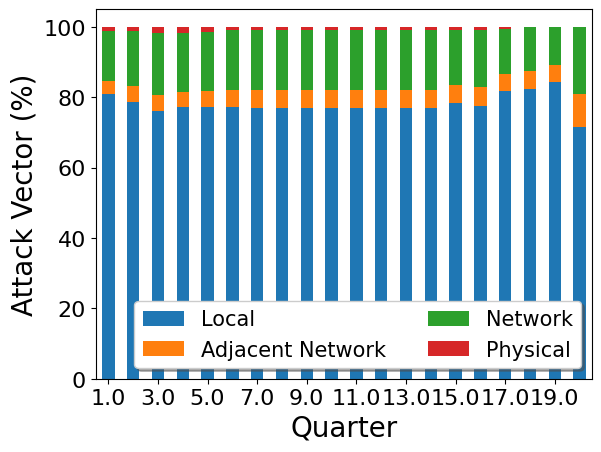

local_per               77.916483
adjacent_network_per     5.063443
network_per             16.070933
physical_per             0.949140
dtype: float64


,local_per,adjacent_network_per,network_per,physical_per
period,,,,
1.0,80.987654,3.703704,14.074074,1.234568
2.0,78.717201,4.373178,15.743440,1.166181
3.0,75.933610,4.564315,17.842324,1.659751
4.0,77.092511,4.405286,16.740088,1.762115
5.0,77.168950,4.566210,16.894977,1.369863
6.0,77.073171,4.878049,17.073171,0.975610
7.0,77.000000,5.000000,17.000000,1.000000
8.0,77.000000,5.000000,17.000000,1.000000
9.0,77.000000,5.000000,17.000000,1.000000


<Figure size 640x480 with 0 Axes>

In [63]:
df_plot = df_quarters[df_quarters['period'] < 21][['period','local_per','adjacent_network_per','network_per','physical_per']]
df_plot.set_index('period',inplace=True)
df_plot.plot(kind='bar',stacked=True,sort_columns=True)

plt.xlabel('Quarter',fontsize=20)
plt.ylabel('Attack Vector (%)',fontsize=20)
plt.xticks(fontsize=16,rotation = 0)
plt.yticks(fontsize=16)
plt.gca().xaxis.set_major_locator(plt.MultipleLocator(2))
plt.gca().yaxis.set_major_locator(plt.MultipleLocator(20))
plt.legend(['Local','Adjacent Network','Network','Physical'],fontsize=15,loc=4,ncol=2,shadow=True)
plt.savefig('../Results/unsupported_attack_vector_v2.pdf', bbox_inches='tight')
plt.show()
plt.tight_layout()

print(df_plot.mean())

df_plot